## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Load and Basic Cleaning

In [5]:
df = pd.read_csv('beijing_dataset.csv')
pd.set_option('display.max_columns', None)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [6]:
df.drop(columns='No', inplace=True)

In [7]:
df = df.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)


In [8]:
df.shape

(43824, 12)

In [9]:
print(f"Year range {df['year'].min()} - {df['year'].max()} ")
print(f"Month range {df['month'].min()} - {df['month'].max()}")
print(f"Day range {df['day'].min()} - {df['day'].max()} ")
print(f"Hour range {df['hour'].min()} - {df['hour'].max()} ")

Year range 2010 - 2014 
Month range 1 - 12
Day range 1 - 31 
Hour range 0 - 23 


## Exploratory Data Analysis

In [10]:
df.isnull().sum()

year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [11]:
df['pm2.5'] = df['pm2.5'].interpolate(method='linear', limit_direction='both')

### 3.1 PM2.5 Distribution

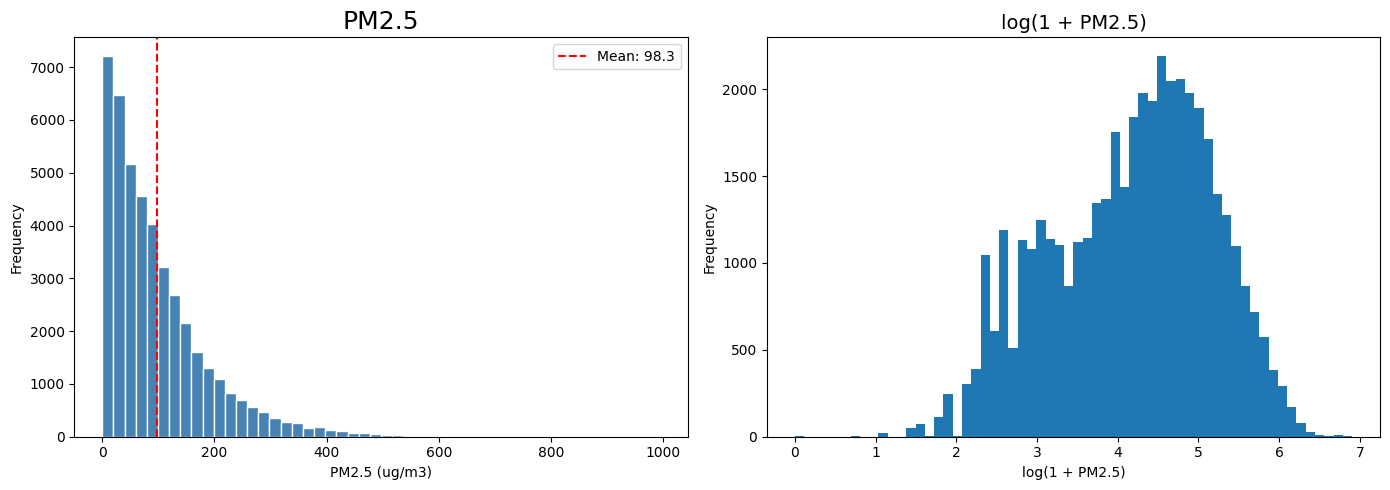

Skewness (raw): 0        129.0
1        129.0
2        129.0
3        129.0
4        129.0
         ...  
43819      8.0
43820     10.0
43821     10.0
43822      8.0
43823     12.0
Name: pm2.5, Length: 43824, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['pm2.5'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5', fontsize=18)
axes[0].set_xlabel('PM2.5 (ug/m3)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['pm2.5'].mean(), color='red', linestyle='--', label=f"Mean: {df['pm2.5'].mean():.1f}")
axes[0].legend()

axes[1].hist(np.log1p(df['pm2.5']), bins=60)
axes[1].set_title('log(1 + PM2.5)', fontsize=14)
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df['pm2.5']}")

### 3.2 Correlation Heatmap

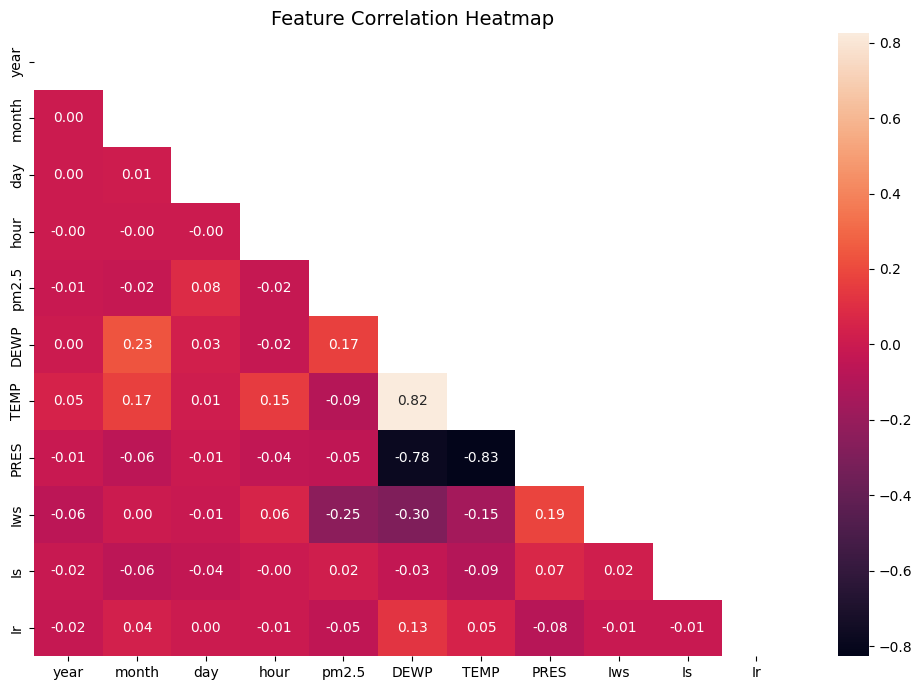

Top correlations with PM2.5
Iws      0.245688
DEWP     0.168500
TEMP     0.089358
day      0.083124
Ir       0.050247
PRES     0.048006
hour     0.023983
month    0.023578
Is       0.019300
year     0.009179


In [13]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask ,annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('Top correlations with PM2.5')
print(corr['pm2.5'].drop('pm2.5').abs().sort_values(ascending=False).to_string())


### 3.3 Temporal Patterns

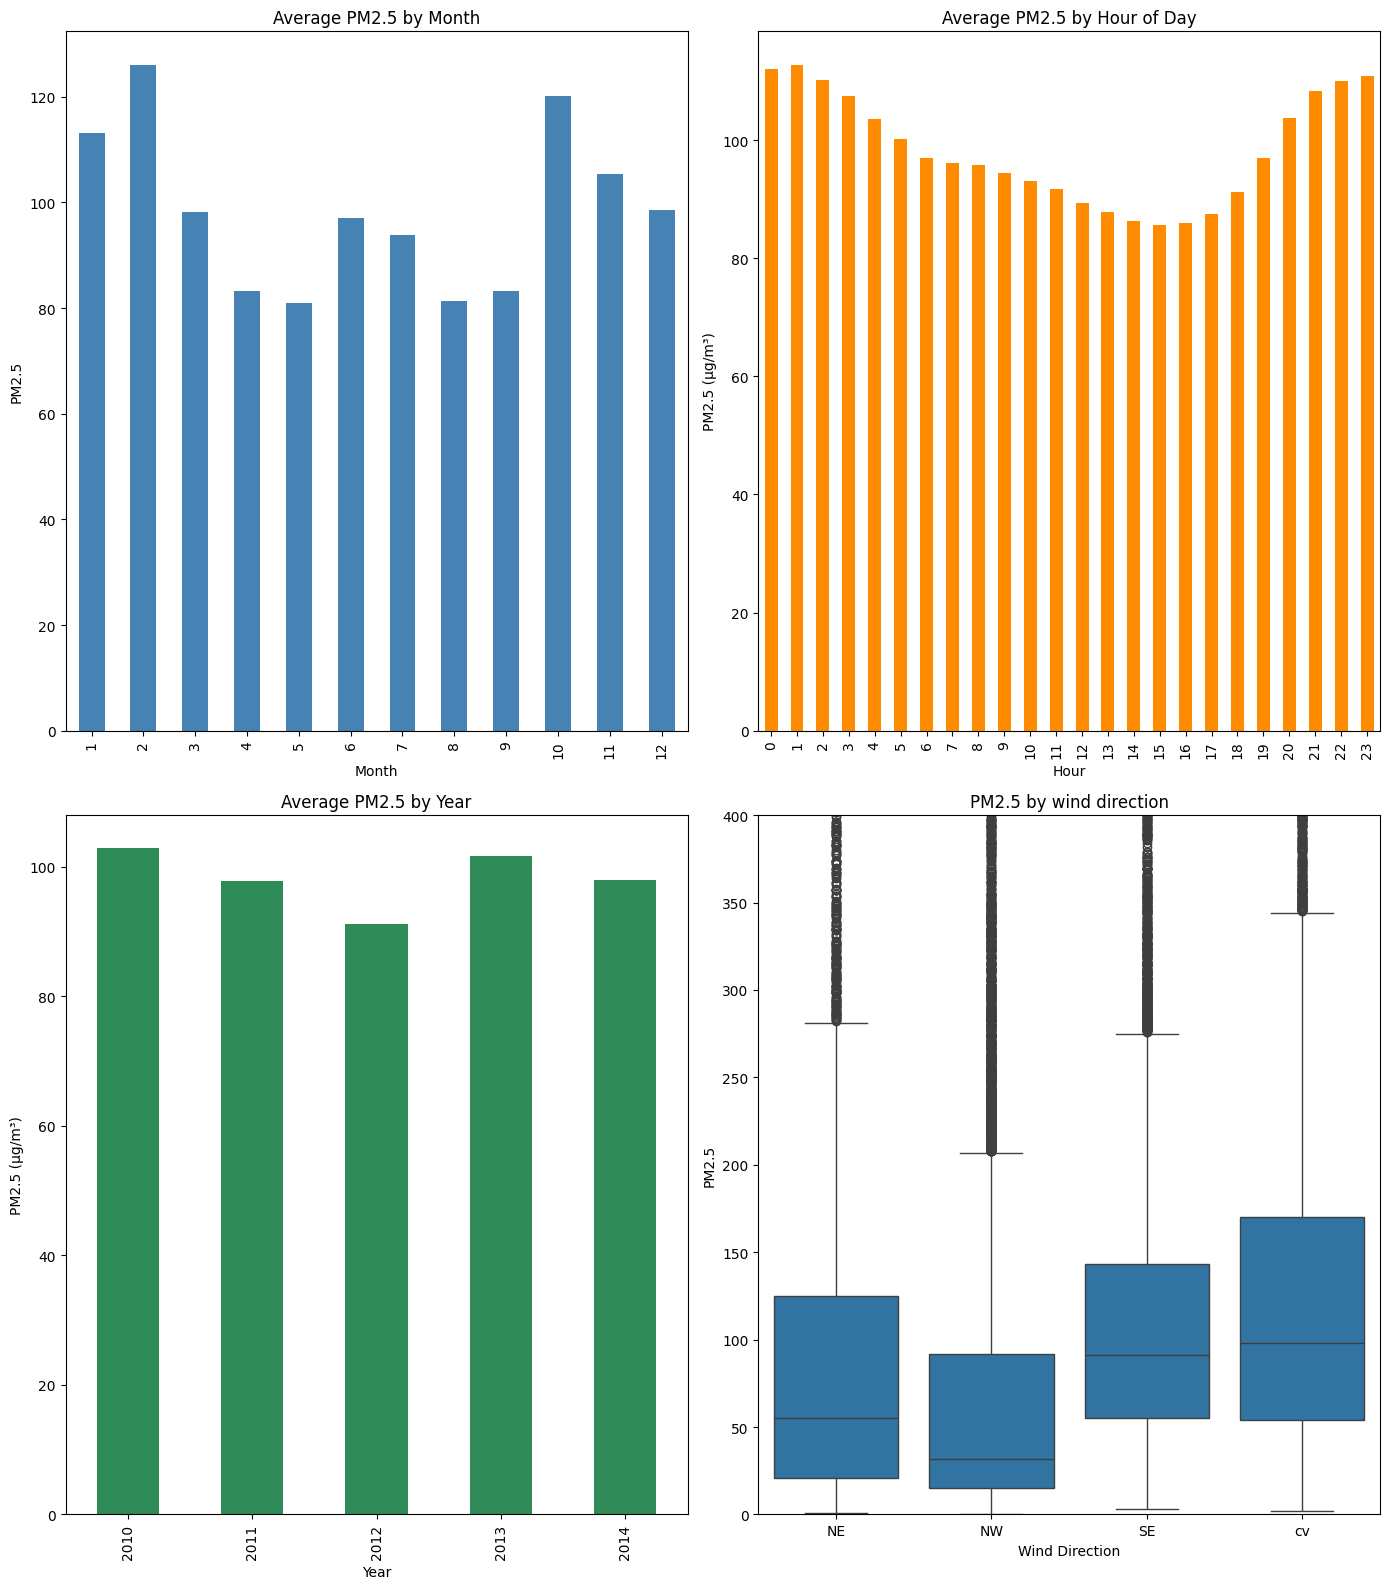

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))

# monthly pattern 
df.groupby('month')['pm2.5'].mean().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5')

# Hourly Pattern
df.groupby('hour')['pm2.5'].mean().plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Average PM2.5 by Hour of Day')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')

# Year-over-year
df.groupby('year')['pm2.5'].mean().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Average PM2.5 by Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Wind direction
sns.boxplot(x=df['cbwd'], y=df['pm2.5'], ax=axes[1, 1], order=['NE', 'NW', 'SE', 'cv'])
axes[1, 1].set_title('PM2.5 by wind direction')
axes[1, 1].set_xlabel('Wind Direction')
axes[1, 1].set_ylabel('PM2.5')
axes[1, 1].set_ylim(0, 400)

plt.tight_layout()
plt.show()


### 3.4 Meteorological Feature Relationship

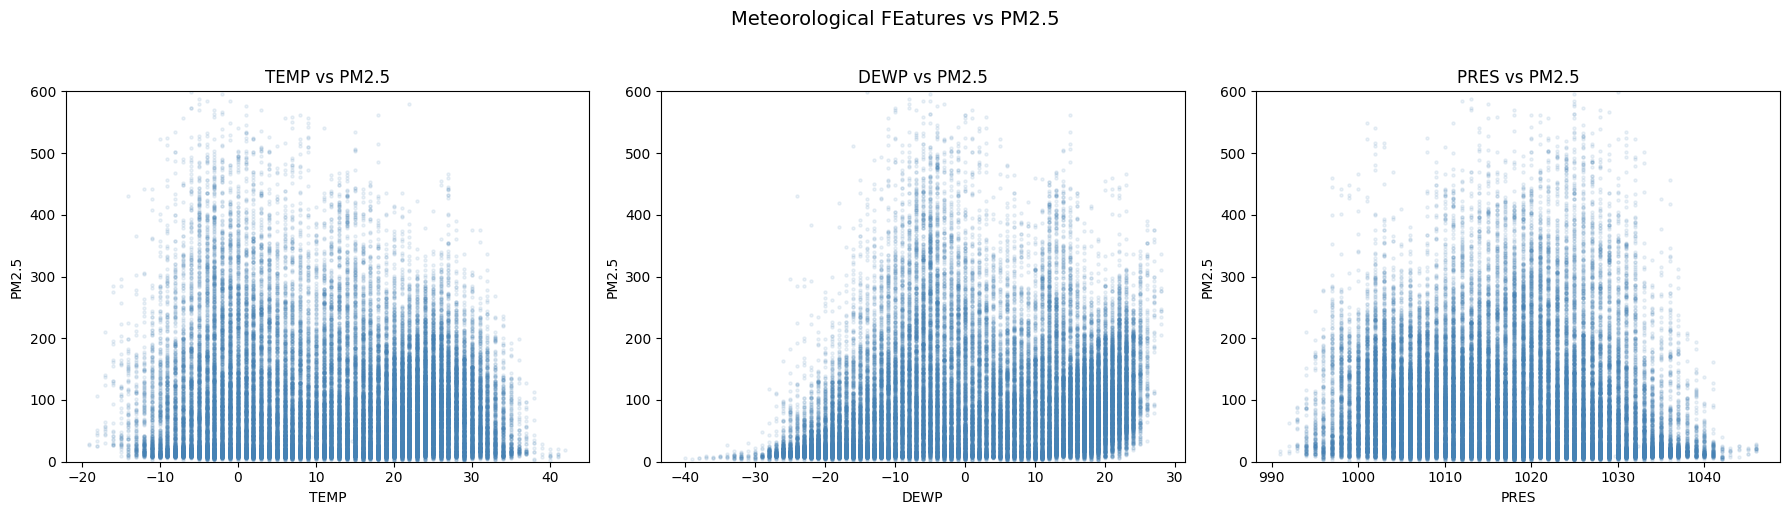

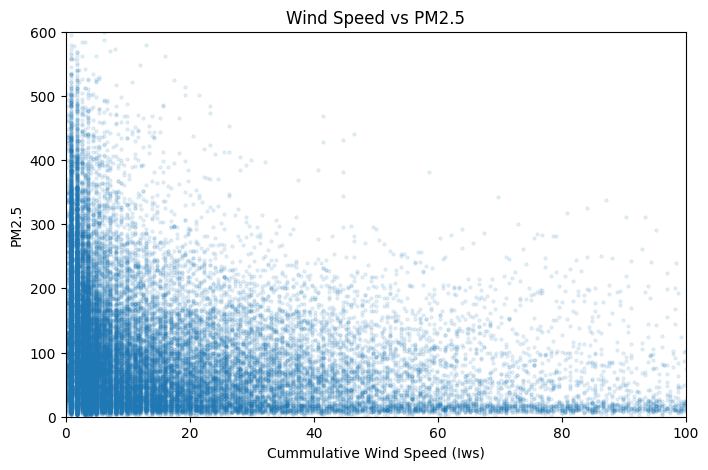

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['TEMP', 'DEWP', 'PRES']):
    ax.scatter(df[col], df['pm2.5'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('PM2.5')
    ax.set_title(f'{col} vs PM2.5')
    ax.set_ylim(0, 600)

plt.suptitle("Meteorological FEatures vs PM2.5", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Iws'], df['pm2.5'], alpha=0.1, s=5)
plt.xlabel('Cummulative Wind Speed (Iws)')
plt.ylabel('PM2.5')
plt.title('Wind Speed vs PM2.5')
plt.ylim(0, 600)
plt.xlim(0, 100)
plt.show()

### 3.5 Temporal Autocorrelation

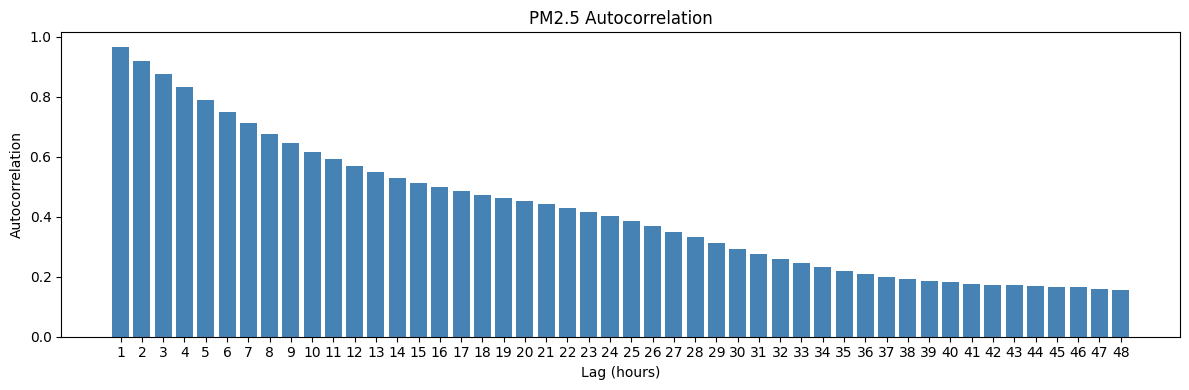

Autocorrelation at lag-1: 0.966
Autocorrelation at lag-2: 0.920
Autocorrelation at lag-24: 0.402


In [16]:
lags = range(1, 49)
autocorr = [df['pm2.5'].autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 4))
plt.bar(lags, autocorr, color='steelblue')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Lag (hours)')
plt.ylabel('Autocorrelation')
plt.title('PM2.5 Autocorrelation')
plt.xticks(list(range(1, 49, 1)))
plt.tight_layout()
plt.show()

print(f"Autocorrelation at lag-1: {df['pm2.5'].autocorr(1):.3f}")
print(f"Autocorrelation at lag-2: {df['pm2.5'].autocorr(2):.3f}")
print(f"Autocorrelation at lag-24: {df['pm2.5'].autocorr(24):.3f}")

### 4. Feature Engineering

In [17]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.drop(columns=['hour', 'month'], inplace=True)

for lag in [1, 2, 3, 6, 12, 24]:
    df[f'pm25_lag{lag}'] = df['pm2.5'].shift(lag)

df['pm25_roll3_mean'] = df['pm2.5'].shift(1).rolling(window=3).mean()
df['pm25_roll6_mean'] = df['pm2.5'].shift(1).rolling(window=6).mean()
df['pm25_roll12_mean'] = df['pm2.5'].shift(1).rolling(window=12).mean()
df['pm25_roll24_mean'] = df['pm2.5'].shift(1).rolling(window=24).mean()

df['pm25_roll3_std'] = df['pm2.5'].shift(1).rolling(window=3).std()
df['pm25_roll6_std'] = df['pm2.5'].shift(1).rolling(window=6).std()
df['pm25_roll12_std'] = df['pm2.5'].shift(1).rolling(window=12).std()
df['pm25_roll24_std'] = df['pm2.5'].shift(1).rolling(window=24).std()

df['pm25_ema3'] = df['pm2.5'].shift(1).ewm(span=3).mean()
df['pm25_ema6'] = df['pm2.5'].shift(1).ewm(span=6).mean()
df['pm25_ema12'] = df['pm2.5'].shift(1).ewm(span=12).mean()
df['pm25_ema24'] = df['pm2.5'].shift(1).ewm(span=24).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"New features: {[c for c in df.columns if 'lag' in c or 'roll' in c or 'sin' in c or 'cos' in c or 'ema' in c]}")

Dataset shape after feature engineering: (43800, 32)
New features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag6', 'pm25_lag12', 'pm25_lag24', 'pm25_roll3_mean', 'pm25_roll6_mean', 'pm25_roll12_mean', 'pm25_roll24_mean', 'pm25_roll3_std', 'pm25_roll6_std', 'pm25_roll12_std', 'pm25_roll24_std', 'pm25_ema3', 'pm25_ema6', 'pm25_ema12', 'pm25_ema24']


### 5. Temporal Train/Test split + log-transform target

In [18]:
split_idx = int(len(df)*0.8)
df_train = df.iloc[:split_idx]
df_test = df.iloc[split_idx:]

print(f"Train: {df_train['year'].min()} - {df_train['year'].max()} ({len(df_train)}) rows")
print(f'Test:  {df_test["year"].min()}–{df_test["year"].max()} ({len(df_test)} rows)')

X_train = df_train.drop('pm2.5', axis=1)
X_test = df_test.drop('pm2.5', axis=1)

y_train = np.log1p(df_train['pm2.5'].values)
y_test = np.log1p(df_test['pm2.5'].values)
y_test_raw = df_test['pm2.5'].values # for final evaluation

Train: 2010 - 2013 (35040) rows
Test:  2014–2014 (8760 rows)


### 6. Preprocessing Pipeline

In [19]:
numerical_cols   = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numerical features:  ', numerical_cols)
print('Categorical features:', categorical_cols)

numerical_pipeline = Pipeline(steps=[('scaler', RobustScaler())])
categorical_pipeline = Pipeline(steps=[('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,   numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'\nProcessed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')

Numerical features:   ['year', 'day', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag6', 'pm25_lag12', 'pm25_lag24', 'pm25_roll3_mean', 'pm25_roll6_mean', 'pm25_roll12_mean', 'pm25_roll24_mean', 'pm25_roll3_std', 'pm25_roll6_std', 'pm25_roll12_std', 'pm25_roll24_std', 'pm25_ema3', 'pm25_ema6', 'pm25_ema12', 'pm25_ema24']
Categorical features: ['cbwd']

Processed train shape: (35040, 34)
Processed test shape:  (8760, 34)


### 7. Model Architecture

In [20]:
model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(256, activation='relu',),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu',),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(1, activation='linear')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,145 (211.50 KB)

 Trainable params: 53,185 (207.75 KB)

 Non-trainable params: 960 (3.75 KB)

### 8. Compile and Train

In [21]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(), metrics=['mae'])

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_test_processed, y_test),
    epochs=200,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.8594 - mae: 2.3039 - val_loss: 0.1350 - val_mae: 0.4226 - learning_rate: 0.0010
Epoch 2/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2886 - mae: 0.5963 - val_loss: 0.0561 - val_mae: 0.2466 - learning_rate: 0.0010
Epoch 3/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2205 - mae: 0.5037 - val_loss: 0.0465 - val_mae: 0.2145 - learning_rate: 0.0010
Epoch 4/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1802 - mae: 0.4487 - val_loss: 0.0482 - val_mae: 0.2222 - learning_rate: 0.0010
Epoch 5/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1617 - mae: 0.4224 - val_loss: 0.0546 - val_mae: 0.2323 - learning_rate: 0.0010
Epoch 6/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1409 - mae: 0.3924 - val_loss: 0.0415 - val_mae: 0.1950 - learning_rate: 0.0010
Epoch 7/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1264 - mae: 0.3723 - val_loss: 0.0420 - val_mae: 0.1927 - learning_rate: 0.0010

### 9. Test Evaluation

In [22]:

y_pred_log = model.predict(X_test_processed).flatten()
y_pred = np.expm1(y_pred_log)   
y_pred = np.maximum(y_pred, 0)   

mae  = mean_absolute_error(y_test_raw, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
r2   = r2_score(y_test_raw, y_pred)

print('Test Set Evaluation')
print(f'MAE: {mae:.2f}  µg/m³')
print(f'RMSE: {rmse:.2f} µg/m³')
print(f'R²: {r2:.4f}')


274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Set Evaluation
MAE: 12.11  µg/m³
RMSE: 21.09 µg/m³
R²: 0.9495


### 10. Loss curve plot

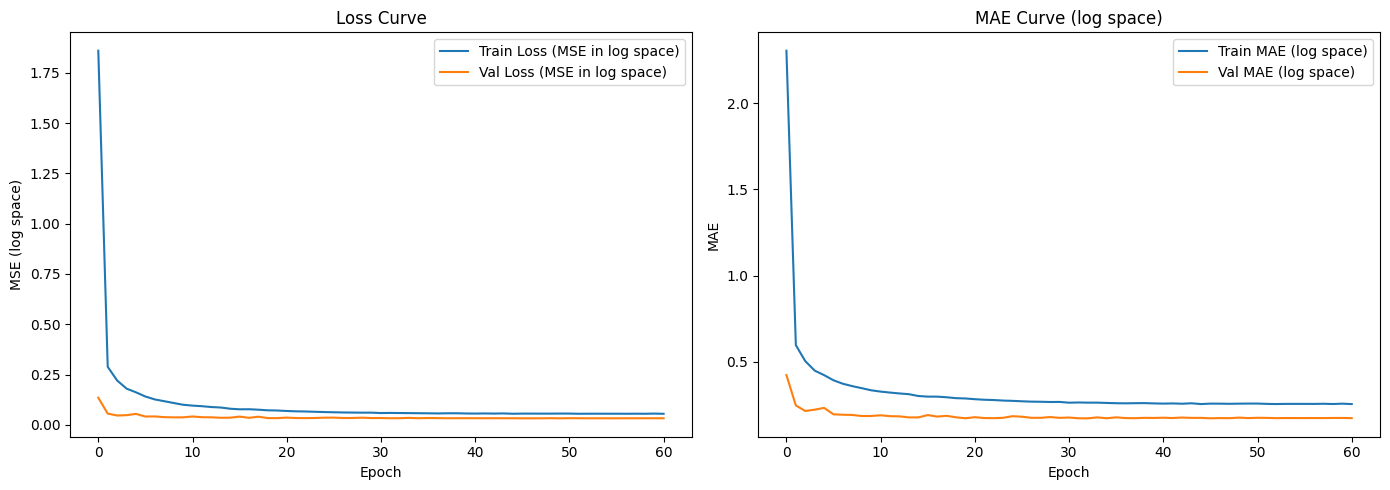

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss (MSE in log space)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE in log space)')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (log space)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE (log space)')
axes[1].plot(history.history['val_mae'], label='Val MAE (log space)')
axes[1].set_title('MAE Curve (log space)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

### 11. Residual Analysis

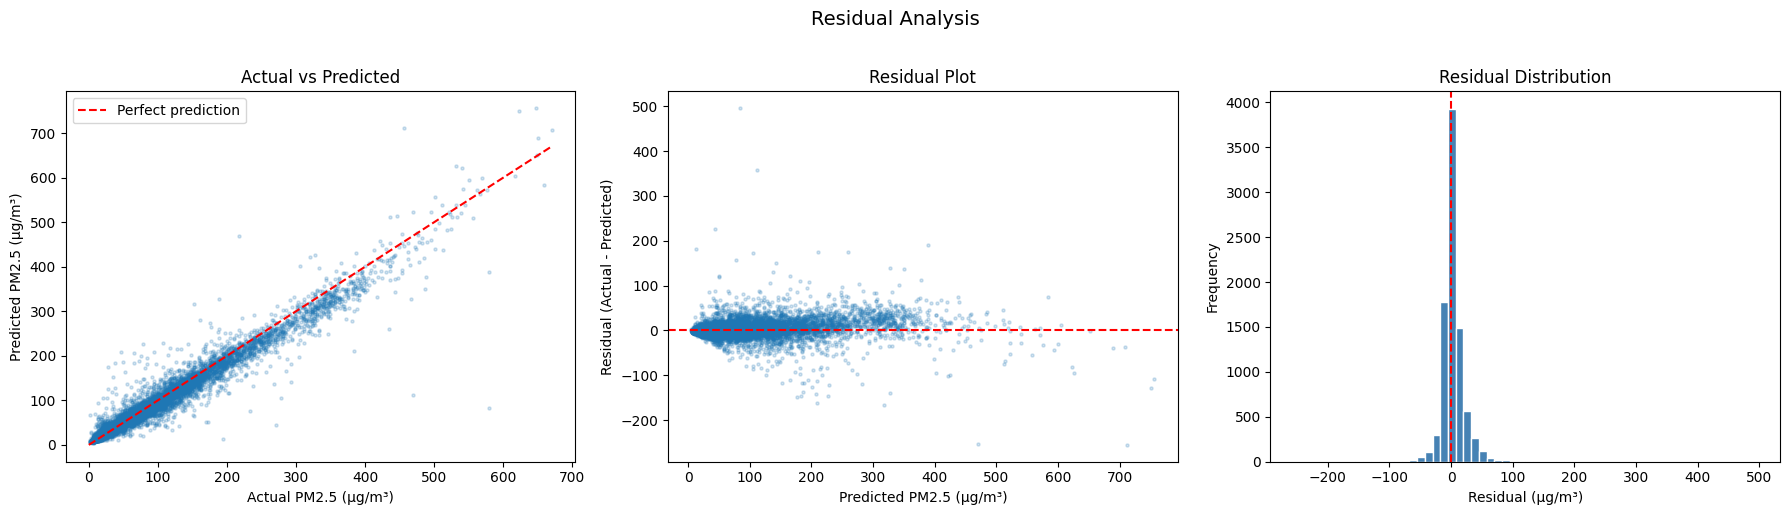

Mean residual: 2.82 µg/m³ (should be near 0 = unbiased)
Std  residual: 20.90 µg/m³


In [24]:
residuals = y_test_raw - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test_raw, y_pred, alpha=0.2, s=5)
axes[0].plot([0, y_test_raw.max()], [0, y_test_raw.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residual plot
axes[1].scatter(y_pred, residuals, alpha=0.2, s=5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (µg/m³)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

# Residual distribution
axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual (µg/m³)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.2f} µg/m³ (should be near 0 = unbiased)')
print(f'Std  residual: {residuals.std():.2f} µg/m³')

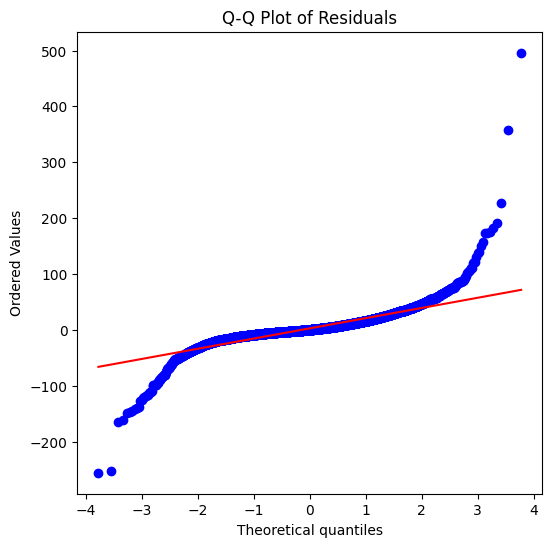

In [25]:
plt.figure(figsize=(6,6))
stats.probplot(y_test_raw - y_pred, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [26]:
model.save("pm25_ann_model.keras")